In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = "DSA210_Project_1.csv"


df = pd.read_csv(file_path)


df.columns = [c.strip() for c in df.columns]

print(df.head())
print(df.info())


         Days Sleep Time Waking Time  Sleep quality  Caffeine mg.  \
0  31.10.2025      23:55       09:20            8.0         200.0   
1   1.11.2025      00:59       10:30            8.0         100.0   
2   2.11.2025      00:23       09:45            8.0         230.0   
3   3.11.2025      01:30       07:39            6.0         250.0   
4   4.11.2025      00:30       09:25            9.0         100.0   

  Screen Time Total App 1 Name App 1 Time App 2 Name App 2 Time  ...  \
0             14:29     TikTok      02:08   WhatsApp      01:00  ...   
1             14:06     TikTok      01:59    Netflix      01:31  ...   
2             13:35    Chrome       01:35    Netflix      01:24  ...   
3             15:03    Preview      02:25     Chrome      02:05  ...   
4             11:51   WhatsApp      02:16     TikTok      01:10  ...   

  App 3 Time          Category 1 name Category 1 Time         Category 2 name  \
0      00:51                   Social           03:28  Productivity & F

In [2]:



def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    if ":" not in x:

        try:
            return float(x)
        except ValueError:
            return np.nan
    parts = x.split(":")
    if len(parts) != 2:
        return np.nan
    h, m = parts
    try:
        return int(h) * 60 + int(m)
    except ValueError:
        return np.nan


df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)


df["ScreenTime_min"] = df["Screen Time Total"].apply(hhmm_to_minutes)
df["StudyTime_min"] = df["Studying Time"].apply(hhmm_to_minutes)


df.rename(columns={"Studying Efficiency": "Productivity"}, inplace=True)


df.loc[df["Productivity"] == -1, "Productivity"] = np.nan

print("\nNumeric columns preview:")
print(df[["Sleep quality", "Caffeine mg.", "ScreenTime_min", "StudyTime_min", "Productivity"]].head())



Numeric columns preview:
   Sleep quality  Caffeine mg.  ScreenTime_min  StudyTime_min  Productivity
0            8.0         200.0           869.0          196.0           7.0
1            8.0         100.0           846.0          219.0           8.0
2            8.0         230.0           815.0          285.0           9.0
3            6.0         250.0           903.0          256.0           7.0
4            9.0         100.0           711.0           65.0           5.0


Scatter plot of Sleep quality vs Date (ignores missing sleep quality).

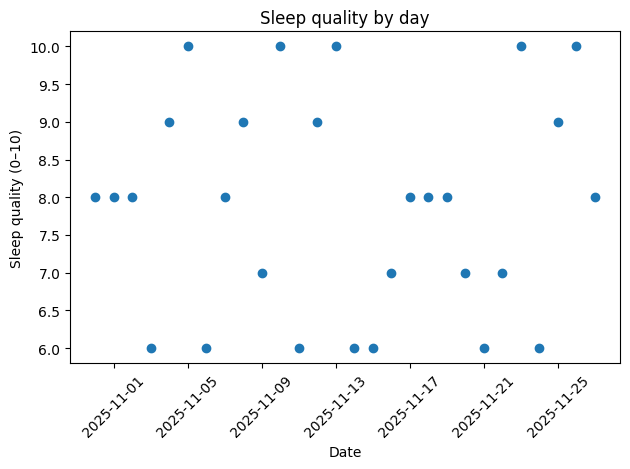

In [ ]:

mask = df["Sleep quality"].notna()
dates = df.loc[mask, "Date"]
sleep_q = df.loc[mask, "Sleep quality"]

plt.figure()
plt.scatter(dates, sleep_q)
plt.xlabel("Date")
plt.ylabel("Sleep quality (0–10)")
plt.title("Sleep quality by day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sorts by date and plots daily trends (one time-series plot per variable).

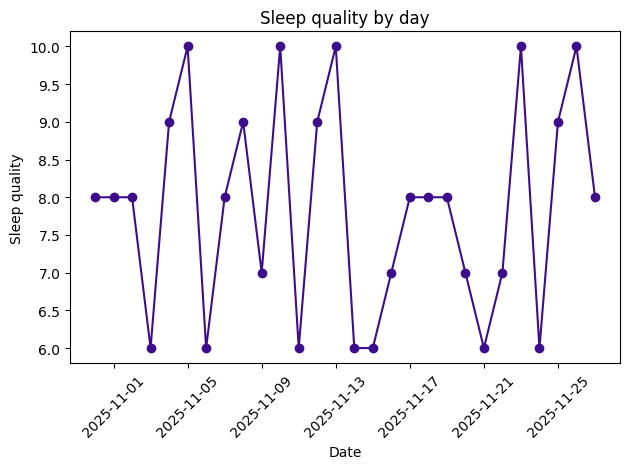

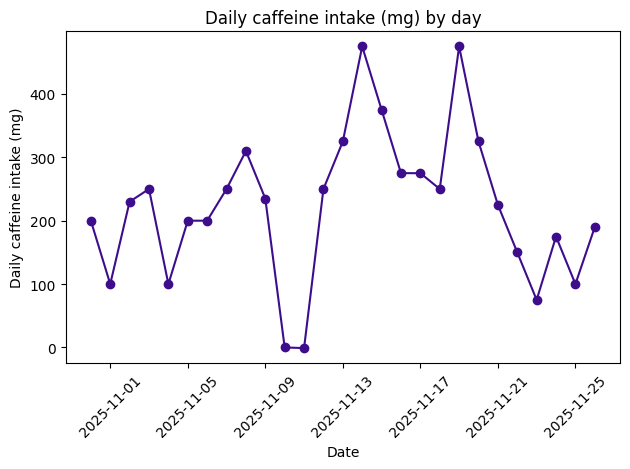

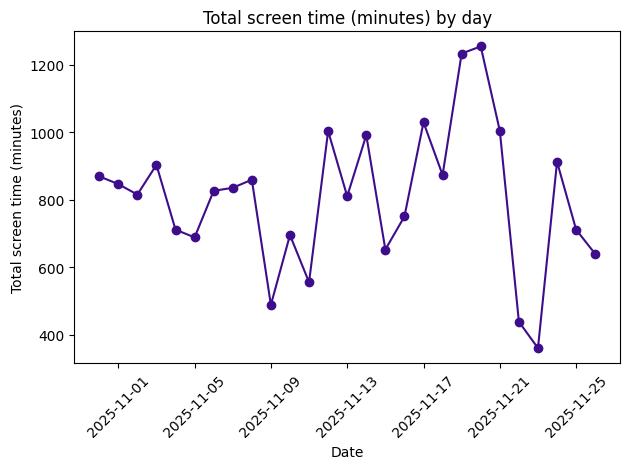

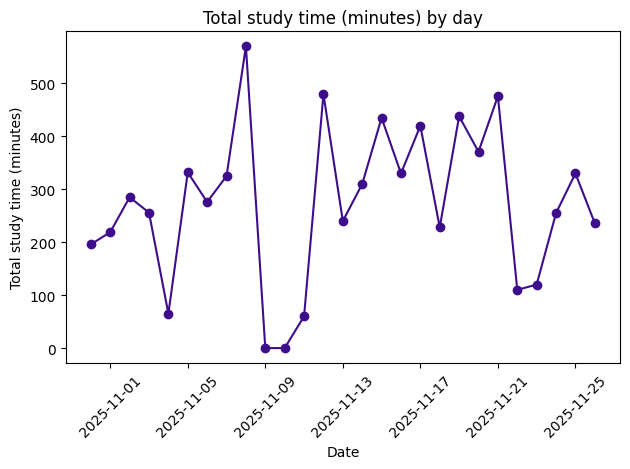

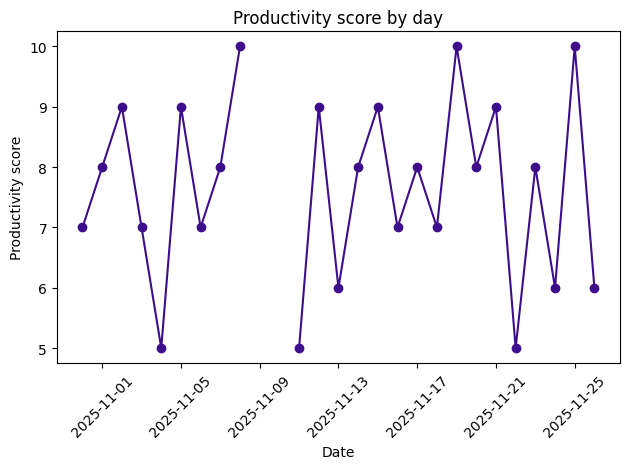

In [ ]:

df = df.sort_values("Date")

vars_by_day = {
    "Sleep quality": "Sleep quality",
    "Caffeine mg.": "Daily caffeine intake (mg)",
    "ScreenTime_min": "Total screen time (minutes)",
    "StudyTime_min": "Total study time (minutes)",
    "Productivity": "Productivity score"
}

for col, ylabel in vars_by_day.items():
    plt.figure()
    plt.plot(df["Date"], df[col], marker="o",color ="#3E0D8C")
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} by day")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Computes sleep duration (hours) and visualizes SleepDuration vs Productivity by day using imshow.

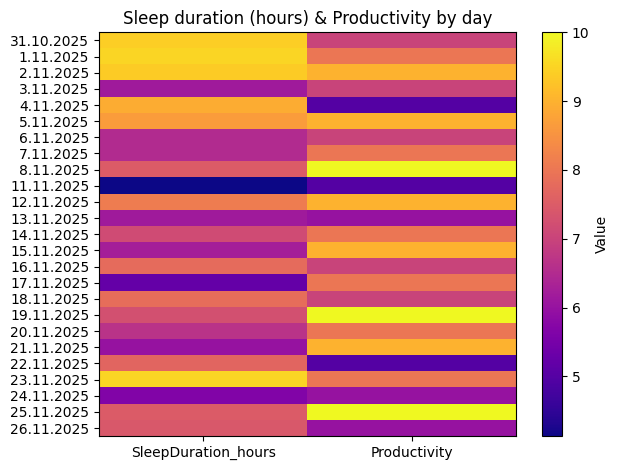

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("DSA210_Project_1.csv")
df.columns = df.columns.str.strip()


df["Productivity"] = df["Studying Efficiency"].replace(-1, np.nan)


def hhmm_to_minutes_time(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if ":" not in x:
        return np.nan
    h, m = x.split(":")
    try:
        return int(h) * 60 + int(m)
    except ValueError:
        return np.nan


df["Sleep_min"] = df["Sleep Time"].apply(hhmm_to_minutes_time)
df["Wake_min"] = df["Waking Time"].apply(hhmm_to_minutes_time)

df["SleepDuration_min"] = df.apply(
    lambda row: np.nan
    if np.isnan(row["Sleep_min"]) or np.isnan(row["Wake_min"])
    else (
        row["Wake_min"] - row["Sleep_min"]
        if row["Wake_min"] > row["Sleep_min"]
        else row["Wake_min"] + 24*60 - row["Sleep_min"]
    ),
    axis=1
)


df["SleepDuration_hours"] = df["SleepDuration_min"] / 60


df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)
df = df.sort_values("Date")


mask = df["SleepDuration_hours"].notna() & df["Productivity"].notna()
df_heat = df.loc[mask, ["Days", "SleepDuration_hours", "Productivity"]]


heat_data = df_heat[["SleepDuration_hours", "Productivity"]].to_numpy()

plt.figure()
plt.imshow(heat_data, aspect="auto",cmap="plasma")
plt.xticks([0, 1], ["SleepDuration_hours", "Productivity"])
plt.yticks(range(len(df_heat)), df_heat["Days"])
plt.colorbar(label="Value")
plt.title("Sleep duration (hours) & Productivity by day")
plt.tight_layout()
plt.show()


Filters caffeine+productivity days, normalizes both to 0–1, and visualizes Caffeine vs Productivity by day with imshow.

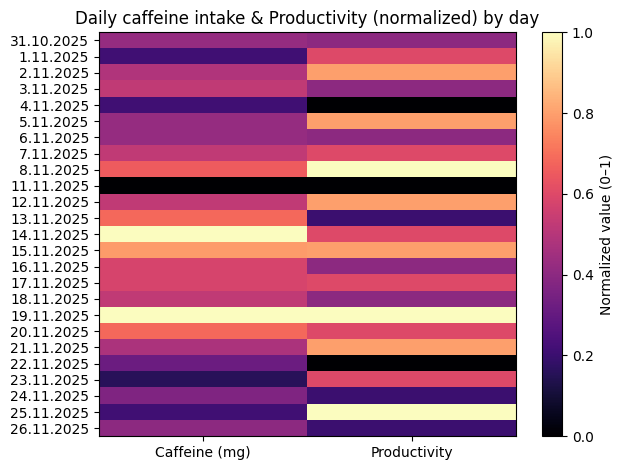

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("DSA210_Project_1.csv")
df.columns = df.columns.str.strip()


df["Productivity"] = df["Studying Efficiency"].replace(-1, np.nan)


df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)
df = df.sort_values("Date")


mask = df["Caffeine mg."].notna() & df["Productivity"].notna()
df_caff = df.loc[mask, ["Days", "Caffeine mg.", "Productivity"]]


heat_data = df_caff[["Caffeine mg.", "Productivity"]].to_numpy(dtype=float)


col_min = np.nanmin(heat_data, axis=0)
col_max = np.nanmax(heat_data, axis=0)
heat_norm = (heat_data - col_min) / (col_max - col_min)

plt.figure()
plt.imshow(heat_norm, aspect="auto",cmap="magma")
plt.xticks([0, 1], ["Caffeine (mg)", "Productivity"])
plt.yticks(range(len(df_caff)), df_caff["Days"])
plt.colorbar(label="Normalized value (0–1)")
plt.title("Daily caffeine intake & Productivity (normalized) by day")
plt.tight_layout()
plt.show()


Visualizing Sleep duration and Sleep quality per day to briefly see if there is a relationship.

Any durations > 16h? (check entries)
Empty DataFrame
Columns: [Days, Sleep Time, Waking Time, SleepDurationHours]
Index: []


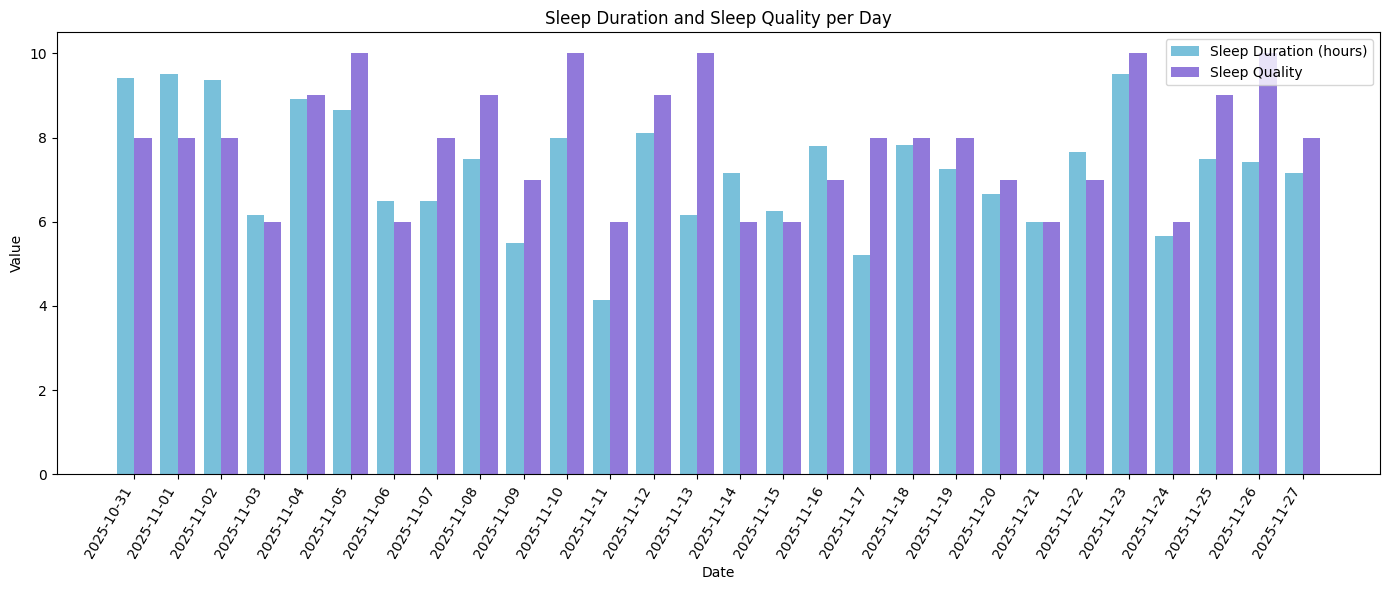

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)

def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or ":" not in s:
        return np.nan
    try:
        h, m = s.split(":")
        return int(h) * 60 + int(m)
    except:
        return np.nan

# Convert bedtime and wake time to minutes since midnight
sleep_min = df["Sleep Time"].apply(hhmm_to_minutes)
wake_min  = df["Waking Time"].apply(hhmm_to_minutes)

# Sleep duration in minutes (handle crossing midnight)
dur_min = wake_min - sleep_min
dur_min = np.where(dur_min < 0, dur_min + 24*60, dur_min)  # add 24h if crossed midnight

df["SleepDurationHours"] = dur_min / 60
df["SleepQuality"] = pd.to_numeric(df["Sleep quality"], errors="coerce")

# Optional: sanity check outliers
print("Any durations > 16h? (check entries)")
print(df.loc[df["SleepDurationHours"] > 16, ["Days", "Sleep Time", "Waking Time", "SleepDurationHours"]])

# One row per day (mean is safe if duplicates exist)
plot_df = (df.groupby("Date", as_index=False)[["SleepDurationHours", "SleepQuality"]]
             .mean()
             .dropna()
             .sort_values("Date"))

# Grouped bar chart (custom colors)
x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(
    x - width/2,
    plot_df["SleepDurationHours"],
    width,
    label="Sleep Duration (hours)",
    color="#79c0da"   # light blue
)
plt.bar(
    x + width/2,
    plot_df["SleepQuality"],
    width,
    label="Sleep Quality",
    color="#9179da"   # purple
)

plt.title("Sleep Duration and Sleep Quality per Day")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(x, plot_df["Date"].dt.strftime("%Y-%m-%d"), rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


Visualizing Studying duration and Efficiency per day to briefly see if there is a relationship.

Any studying durations > 16h? (check entries)
Empty DataFrame
Columns: [Days, Studying Time, StudyDurationHours]
Index: []


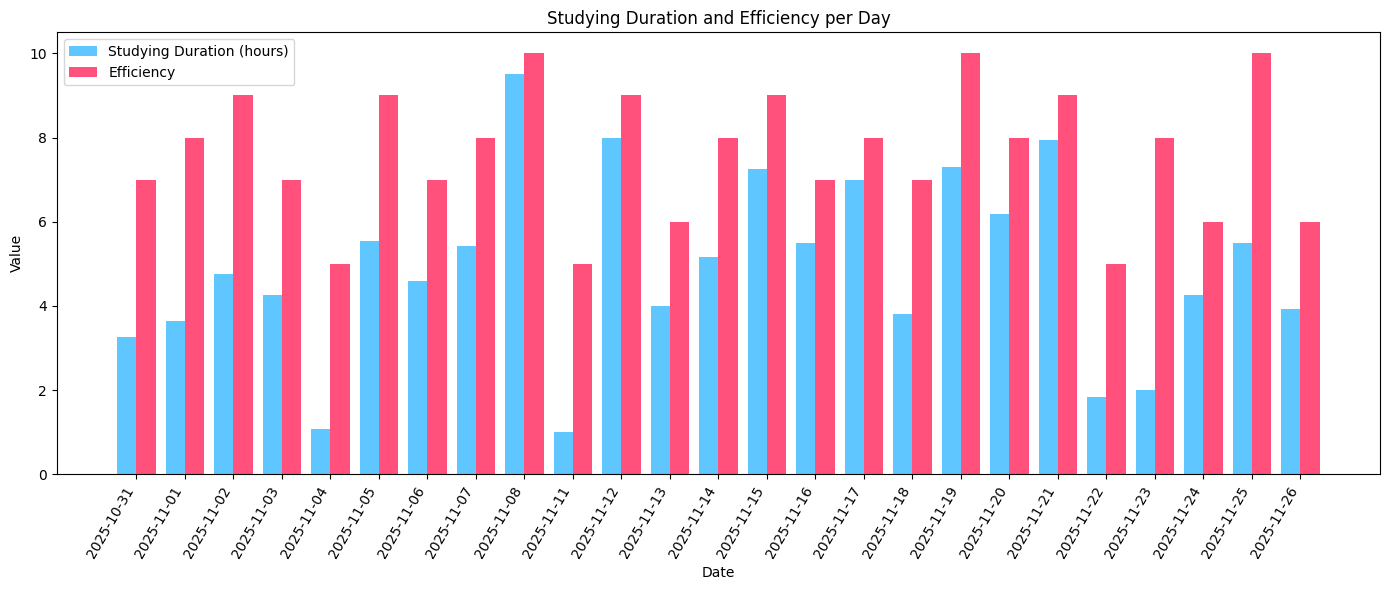

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)

def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or ":" not in s:
        return np.nan
    try:
        h, m = s.split(":")
        return int(h) * 60 + int(m)
    except:
        return np.nan

# Convert studying time (duration) to minutes
study_min = df["Studying Time"].apply(hhmm_to_minutes)

# Studying duration in hours
df["StudyDurationHours"] = study_min / 60

# Efficiency (your file uses "Studying Efficiency")
# If you already renamed it to "Productivity", this code will still work.
if "Studying Efficiency" in df.columns:
    df["Efficiency"] = pd.to_numeric(df["Studying Efficiency"], errors="coerce")
elif "Productivity" in df.columns:
    df["Efficiency"] = pd.to_numeric(df["Productivity"], errors="coerce")
else:
    raise KeyError("Could not find 'Studying Efficiency' or 'Productivity' column.")

# Optional: sanity check outliers
print("Any studying durations > 16h? (check entries)")
print(df.loc[df["StudyDurationHours"] > 16, ["Days", "Studying Time", "StudyDurationHours"]])

# One row per day (mean is safe if duplicates exist)
plot_df = (df.groupby("Date", as_index=False)[["StudyDurationHours", "Efficiency"]]
             .mean()
             .dropna()
             .sort_values("Date"))

# Grouped bar chart (custom colors)
x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(
    x - width/2,
    plot_df["StudyDurationHours"],
    width,
    label="Studying Duration (hours)",
    color="#60c6ff"
)
plt.bar(
    x + width/2,
    plot_df["Efficiency"],
    width,
    label="Efficiency",
    color="#ff517c"
)

plt.title("Studying Duration and Efficiency per Day")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(x, plot_df["Date"].dt.strftime("%Y-%m-%d"), rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


Visualizing Caffeine intake (in dg) and Efficiency per day to briefly see if there is a relationship.

Any caffeine intake > 600 mg? (check entries)
Empty DataFrame
Columns: [Days, Caffeine mg., CaffeineMg]
Index: []


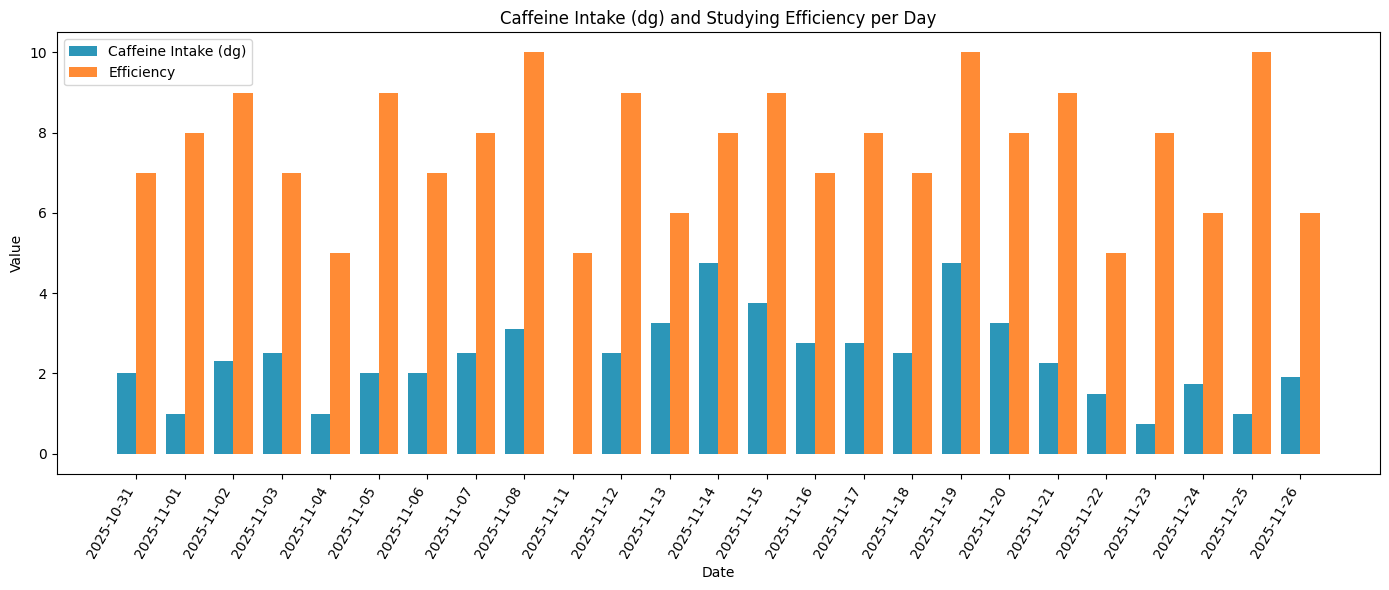

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Days"], dayfirst=True)

# Caffeine in mg -> dg (decigram)
df["CaffeineMg"] = pd.to_numeric(df["Caffeine mg."], errors="coerce")
df["CaffeineDg"] = df["CaffeineMg"] / 100  # 100 mg = 1 dg

# Efficiency column (robust to renaming)
if "Studying Efficiency" in df.columns:
    df["Efficiency"] = pd.to_numeric(df["Studying Efficiency"], errors="coerce")
elif "Productivity" in df.columns:
    df["Efficiency"] = pd.to_numeric(df["Productivity"], errors="coerce")
else:
    raise KeyError("Could not find 'Studying Efficiency' or 'Productivity' column.")

# Optional: sanity check caffeine outliers (still check in mg)
print("Any caffeine intake > 600 mg? (check entries)")
print(df.loc[df["CaffeineMg"] > 600, ["Days", "Caffeine mg.", "CaffeineMg"]])

# One row per day (mean is safe if duplicates exist)
plot_df = (
    df.groupby("Date", as_index=False)[["CaffeineDg", "Efficiency"]]
      .mean()
      .dropna()
      .sort_values("Date")
)

# Grouped bar chart (custom colors)
x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(
    x - width/2,
    plot_df["CaffeineDg"],
    width,
    label="Caffeine Intake (dg)",
    color="#2c96b8"
)
plt.bar(
    x + width/2,
    plot_df["Efficiency"],
    width,
    label="Efficiency",
    color="#ff8b35"
)

plt.title("Caffeine Intake (dg) and Studying Efficiency per Day")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(x, plot_df["Date"].dt.strftime("%Y-%m-%d"), rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
